In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
elements_data = pd.read_csv('all_elements.csv')
pcs_data = pd.read_csv('all_pcs.csv')

In [3]:
elements_data = elements_data.drop(columns = 'Unnamed: 0')

In [4]:
pcs_data = pcs_data.drop(columns = 'Unnamed: 0')

In [5]:
elements_data['Skater'].nunique()

72

In [6]:
pcs_data['Skater'].nunique()

72

In [7]:
# Both datasets have the same number of skaters

In [8]:
display(elements_data.head())
display(pcs_data.head())

,Skater,Element #,Element,Base Value,Final Score,GOE,Gender,Competition,Season,Segment
0,Deniss VASILJEVS,10,FCCoSp4,3.5,4.75,1.25,Men,Allen,2024,Free Skate
1,Deniss VASILJEVS,11,FSSp4,3.0,3.94,0.94,Men,Allen,2024,Free Skate
2,Deniss VASILJEVS,12,ChSq1,3.0,4.71,1.71,Men,Allen,2024,Free Skate
3,Deniss VASILJEVS,2,3Lz+3T,10.1,11.79,1.69,Men,Allen,2024,Free Skate
4,Deniss VASILJEVS,3,3A+2A+SEQ,11.3,11.99,0.69,Men,Allen,2024,Free Skate


,Skater,Component,J1,J2,J3,J4,J5,J6,J7,J8,J9,Panel_Avg,Gender,Competition,Season,Segment
0,Kevin AYMOZ,Composition,9.00,9.00,9.25,8.50,9.00,9.50,9.25,9.50,9.50,9.21,Men,Allen,2024,Free Skate
1,Kevin AYMOZ,Presentation,9.25,9.00,9.50,8.75,9.50,9.25,9.50,9.50,9.50,9.36,Men,Allen,2024,Free Skate
2,Kevin AYMOZ,Skating Skills,9.00,8.75,9.25,9.00,9.50,8.75,8.75,9.00,9.50,9.04,Men,Allen,2024,Free Skate
3,Ilia MALININ,Composition,8.75,8.75,8.75,8.75,8.75,9.00,9.50,9.00,8.75,8.82,Men,Allen,2024,Free Skate
4,Ilia MALININ,Presentation,8.50,8.50,9.00,8.75,8.75,9.25,9.50,9.25,8.75,8.89,Men,Allen,2024,Free Skate


### Main Goals for the Data Analysis/Visualization Aspect of this Project:

I have 3 questions I want to answer:

1) Does technical difficulty influence artistic scores?
2) Are some judges systematically stricter?
3) Are harder elements worth it or do scores in pcs make up for it? -- kinda answered with question 1

**Let's start by looking at the first question:**
Essentially, I am trying to find if skaters with higher technical base value receive higher PCS, even after controlling for execution (GOE)? Are judges influenced by their technical abilities when scoring for PCS?

To solve this, I have some steps in mind:

1) Aggregate to get a dataset containing:
    - Skater, Competition, Total_Base_Value, Avg_GOE, PCS_Total

In [9]:
# Aggregating each dataset
elements_grouped = elements_data.groupby(['Skater', 'Competition']).agg(Total_Base_Value=('Base Value', 'sum'),Avg_GOE=('GOE', 'mean'))
pcs_grouped = pcs_data.groupby(['Skater', 'Competition']).agg(PCS_Total=('Panel_Avg', 'sum'))

#concatenating the datasets
all_grouped = pd.concat([elements_grouped, pcs_grouped],axis=1)

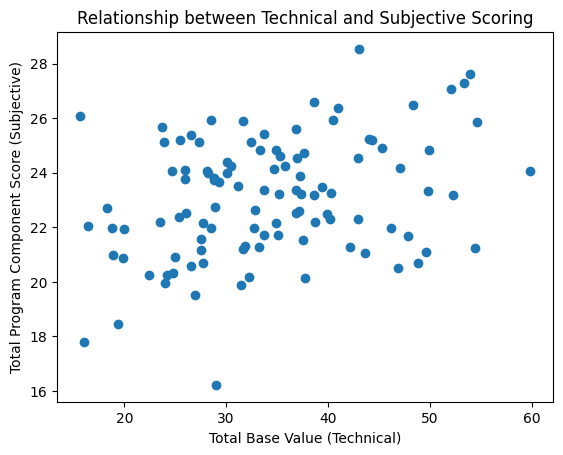

R-Value: 0.33027288630260604


In [10]:
plt.scatter(data = all_grouped, x = 'Total_Base_Value', y = 'PCS_Total')
plt.title('Relationship between Technical and Subjective Scoring')
plt.xlabel('Total Base Value (Technical)')
plt.ylabel('Total Program Component Score (Subjective)')
plt.show();

r = all_grouped["Total_Base_Value"].corr(all_grouped["PCS_Total"])
print("R-Value:",r)

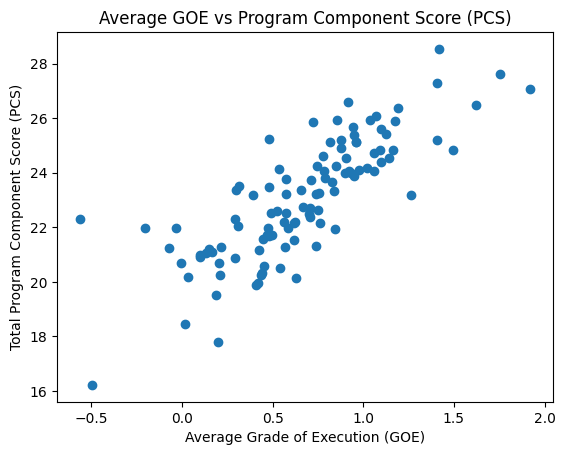

R-Value: 0.8023847780969607


In [11]:
plt.scatter(data = all_grouped, x = 'Avg_GOE', y = 'PCS_Total')
plt.title('Average GOE vs Program Component Score (PCS)')
plt.xlabel('Average Grade of Execution (GOE)')
plt.ylabel('Total Program Component Score (PCS)')
plt.show();

r = all_grouped["Avg_GOE"].corr(all_grouped["PCS_Total"])
print("R-Value:",r)

In [12]:
# INTERRETATION:
# GOE means that skaters are executing their elements really well. Since average GOE has a high correlation with total PCS,
    # Cleaner skating --> high PCS
    # Messy skating --> low PCS

# The relationship between Total_Base_Value and PCS is only 0.3. This means that doing harder skills does not necessarily mean a high PCS
    # What matters most is execution, not difficulty
    # Execution is rewarded through GOE AND PCS

In [13]:
# Let's look at significance now
import statsmodels.formula.api as smf

In [16]:
model = smf.ols(formula='PCS_Total ~ Total_Base_Value + Avg_GOE', data=all_grouped).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              PCS_Total   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     100.2
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           5.64e-25
Time:                        00:06:24   Log-Likelihood:                -177.74
No. Observations:                 107   AIC:                             361.5
Df Residuals:                     104   BIC:                             369.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           19.5302      0.464     42.128      0.000      18.611      20.449
Total_Base_Value     0.0279      0.013      2.098      0.038       0.002       0.054
Avg_GOE              3.8792      0.300     12.928      0.000       3.284       4.474
==============================================================================
Omnibus:                        0.145   Durbin-Watson:                   1.295
Prob(Omnibus):                  0.930   Jarque-Bera (JB):                0.128
Skew:                           0.078   Prob(JB):                        0.938
Kurtosis:                       2.933   Cond. No.                         134.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
# Total base value is significant and has a little effect on PCS_total
    # for every unit increase in Total_Base_Value, there is a 0.0279 increse in PCS

# Avg_GOE is very much significant and has a larger effect on PCS_total
    # for every unit increase in Avg_GOE, there is a 3.8792 increse in PCS

#Skaters attempting harder elements (higher Base Value) get slightly higher PCS
    # suggesting a small halo effect, but it’s minor compared to execution.

# This is a short deliverable because of a deadline, but I kept working on it after the 12:00 AM deadline

In [20]:
all_grouped

Total_Base_Value   Avg_GOE  PCS_Total
Skater            Competition                                       
Adam SIAO HIM FA  France                   45.3  0.876667      24.92
Aleksa RAKIC      Canada                   47.9  0.477778      21.68
Aleksandr SELEVKO France                   34.7  0.535000      24.15
Alysa LIU         Canada                   18.3  0.705000      22.72
                  Japan                    28.1  0.785000      24.07
...                                         ...       ...        ...
Yelim KIM         Japan                    31.9  0.740000      21.32
Yuma KAGIYAMA     GPFinal                  53.4  1.407778      27.28
                  Japan                    52.1  1.922500      27.07
Yuna AOKI         Allen                    35.2  0.575556      23.22
                  Japan                    23.9  0.961429      25.11

[107 rows x 3 columns]

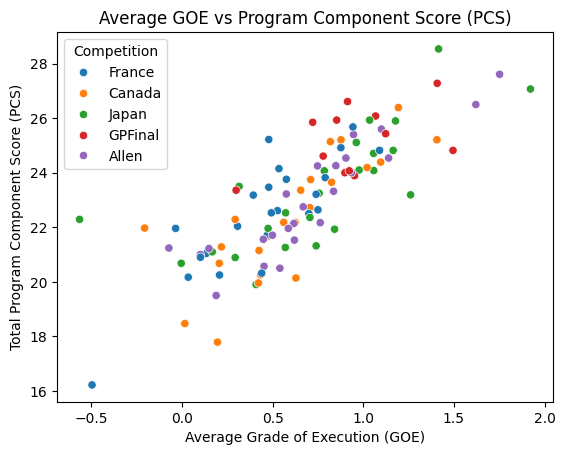

R-Value: 0.8023847780969607


In [21]:
sns.scatterplot(data=all_grouped, x='Avg_GOE', y='PCS_Total', hue='Competition')

plt.title('Average GOE vs Program Component Score (PCS)')
plt.xlabel('Average Grade of Execution (GOE)')
plt.ylabel('Total Program Component Score (PCS)')
plt.show()

r = all_grouped["Avg_GOE"].corr(all_grouped["PCS_Total"])
print("R-Value:", r)

In [22]:
# country does not have a large influence

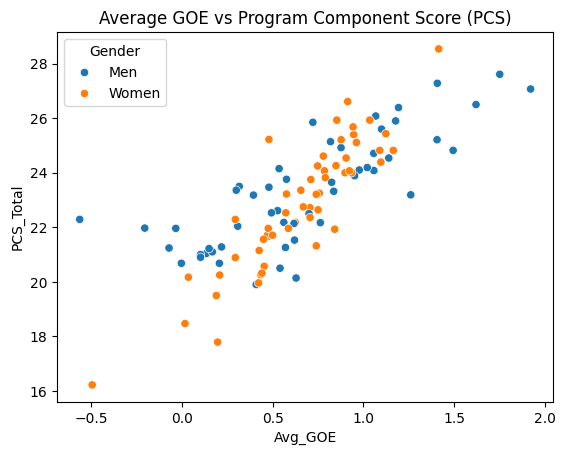

In [25]:
elements_grouped = elements_data.groupby(['Skater', 'Competition']).agg(
    Total_Base_Value=('Base Value', 'sum'),
    Avg_GOE=('GOE', 'mean'),
    Gender=('Gender', 'first')
)

pcs_grouped = pcs_data.groupby(['Skater', 'Competition']).agg(
    PCS_Total=('Panel_Avg', 'sum')
)

all_grouped = pd.concat([elements_grouped, pcs_grouped], axis=1).reset_index()

sns.scatterplot(data=all_grouped, x='Avg_GOE', y='PCS_Total', hue='Gender')
plt.title('Average GOE vs Program Component Score (PCS)')
plt.show();

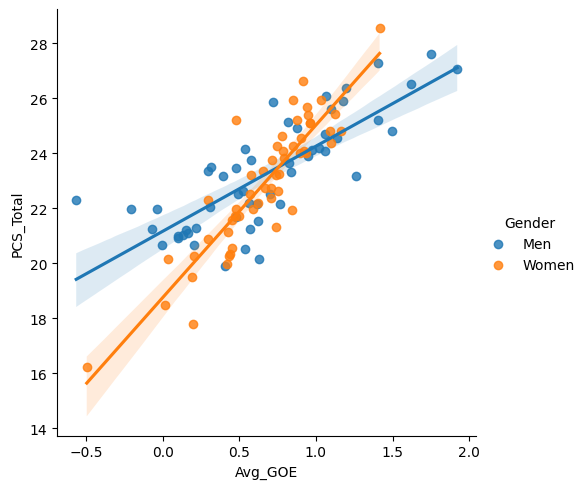

In [26]:
sns.lmplot(data=all_grouped, x="Avg_GOE", y="PCS_Total", hue="Gender")

#### Overall Findings:

- This relationship exists for both men and women. The regression lines in the second graph show an upward trend for both genders, indicating that better execution quality is associated with higher PCS regardless of gender.

- The relationship appears stronger for women. The regression line for women is steeper than for men, suggesting that increases in GOE may correspond to larger increases in PCS for women compared to men.
    - This indicates that PCS may be more sensitive to changes in execution quality for women, meaning improvements in GOE are associated with larger increases in PCS compared to men.

- Men show a wider range of GOE values. In the scatterplot, men extend further to the right (higher Avg_GOE values), indicating that male skaters in this dataset achieved higher average execution scores than female skaters.

- PCS scores overlap heavily between genders. Despite differences in GOE ranges, both men and women cluster within a similar PCS range (roughly 22–26), suggesting that program component scoring is relatively comparable across genders.

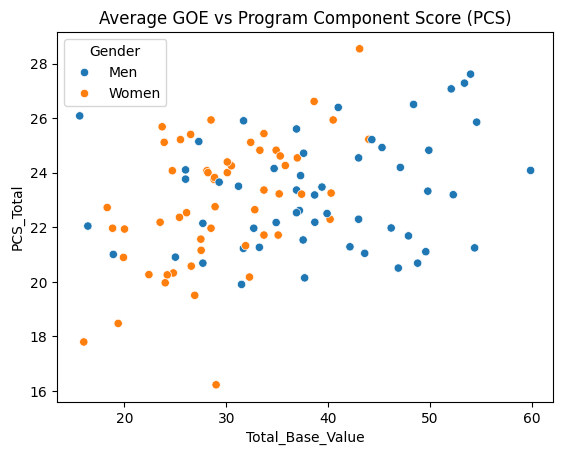

In [27]:
elements_grouped = elements_data.groupby(['Skater', 'Competition']).agg(
    Total_Base_Value=('Base Value', 'sum'),
    Avg_GOE=('GOE', 'mean'),
    Gender=('Gender', 'first')
)

pcs_grouped = pcs_data.groupby(['Skater', 'Competition']).agg(
    PCS_Total=('Panel_Avg', 'sum')
)

all_grouped = pd.concat([elements_grouped, pcs_grouped], axis=1).reset_index()

sns.scatterplot(data=all_grouped, x='Total_Base_Value', y='PCS_Total', hue='Gender')
plt.title('Average GOE vs Program Component Score (PCS)')
plt.show();

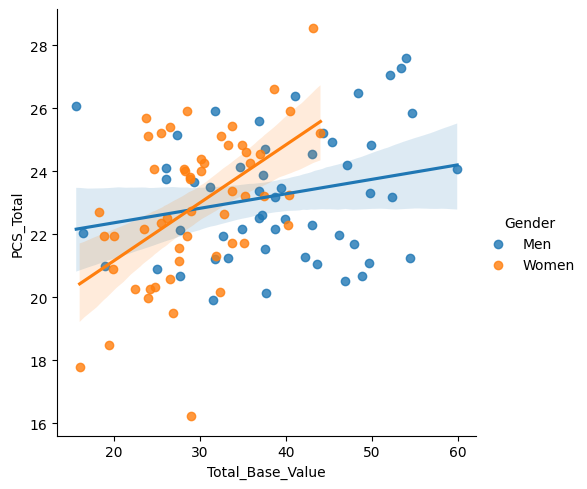

In [28]:
sns.lmplot(data=all_grouped, x="Total_Base_Value", y="PCS_Total", hue="Gender")

- The relationship appears stronger for women. The regression line for women is steeper than for men, suggesting that increases in Total Base Value correspond to larger increases in PCS for women compared to men. This indicates that PCS may be more sensitive to increases in technical difficulty for women, meaning higher base value programs are associated with larger increases in PCS relative to men.
- Total base value also does not extend as far as men does, meaning that men tend to attempt more technically complex elements in their programs

#### Are some judges systematically stricter?

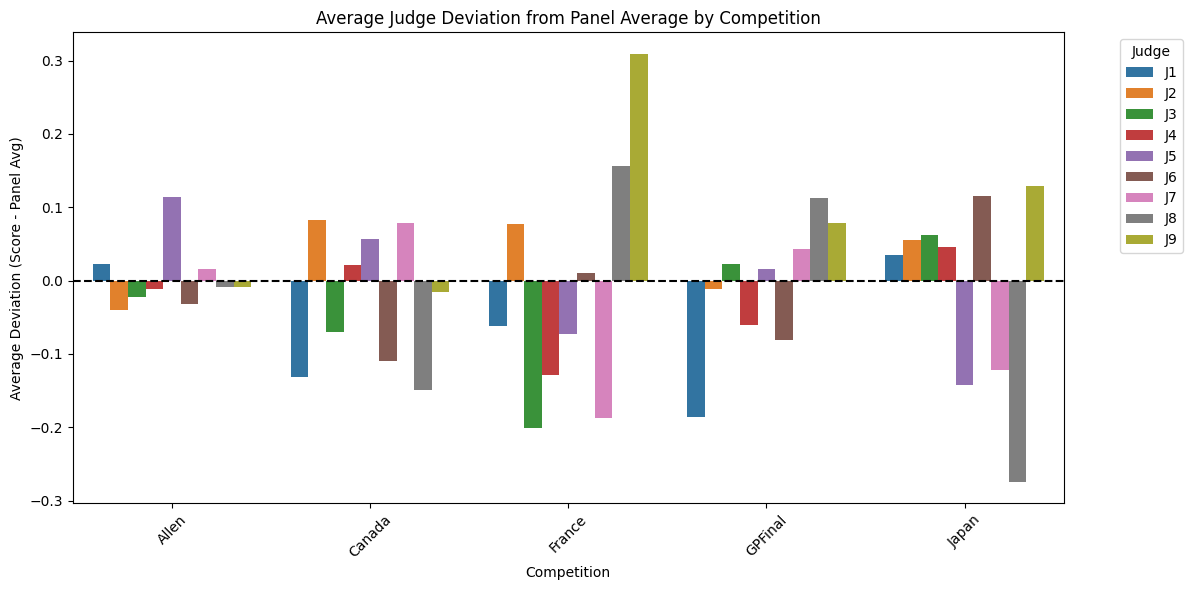

In [38]:
# list of judge columns
judge_cols = ['J1','J2','J3','J4','J5','J6','J7','J8','J9']

# melt the dataframe so we can handle judges as a single column
diff_df = pcs_data.melt(
    id_vars=['Skater','Competition','Panel_Avg'], 
    value_vars=judge_cols, 
    var_name='Judge', 
    value_name='Score'
)

# compute deviation from panel average
diff_df['Deviation'] = diff_df['Score'] - diff_df['Panel_Avg']

# average deviation per judge per competition
judge_comp_avg = diff_df.groupby(['Competition','Judge'])['Deviation'].mean().reset_index()

# plot
plt.figure(figsize=(12,6))
sns.barplot(
    data=judge_comp_avg,
    x='Competition',
    y='Deviation',
    hue='Judge'
)
plt.axhline(0, color='black', linestyle='--')  # reference line at 0
plt.title('Average Judge Deviation from Panel Average by Competition')
plt.ylabel('Average Deviation (Score - Panel Avg)')
plt.xlabel('Competition')
plt.legend(title='Judge', bbox_to_anchor=(1.05, 1), loc='upper left')  # move legend outside
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/8t/bwgvq_w97yd84srzdk9kxpkc0000gn/T/ipykernel_7945/67073491.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


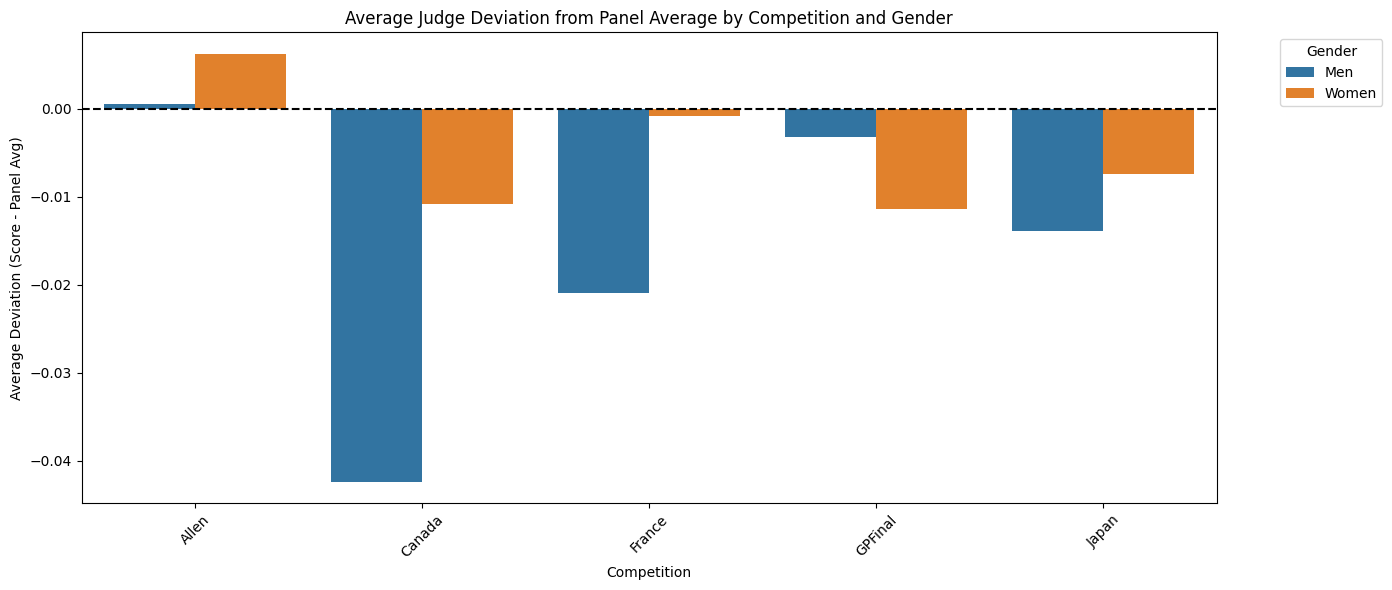

In [41]:
# melt the dataframe so we can handle judges as a single column
diff_df = pcs_data.melt(
    id_vars=['Skater','Competition','Gender','Panel_Avg'],  # include Gender
    value_vars=judge_cols, 
    var_name='Judge', 
    value_name='Score'
)

# compute deviation from panel average
diff_df['Deviation'] = diff_df['Score'] - diff_df['Panel_Avg']

# average deviation per judge per competition per gender
judge_comp_gender_avg = diff_df.groupby(['Competition','Judge','Gender'])['Deviation'].mean().reset_index()

# plot
plt.figure(figsize=(14,6))
sns.barplot(
    data=judge_comp_gender_avg,
    x='Competition',
    y='Deviation',
    hue='Gender',  # now coloring by gender
    ci=None
)
plt.axhline(0, color='black', linestyle='--')  # reference line at 0
plt.title('Average Judge Deviation from Panel Average by Competition and Gender')
plt.ylabel('Average Deviation (Score - Panel Avg)')
plt.xlabel('Competition')
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')  # move legend outside
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Additional: Let's try to predict how Alysa Liu will do at olympics and how she actually did

In [46]:
# let's collect more data on alysa liu

elements_data[elements_data['Skater'] =="Alysa LIU"]

,Skater,Element #,Element,Base Value,Final Score,GOE,Gender,Competition,Season,Segment
284,Alysa LIU,10,FCSp3,2.8,3.32,0.52,Women,Canada,2024,Free Skate
285,Alysa LIU,11,ChSq1,3.0,3.79,0.79,Women,Canada,2024,Free Skate
286,Alysa LIU,12,LSp3,2.4,3.05,0.65,Women,Canada,2024,Free Skate
287,Alysa LIU,3,2A,3.3,4.01,0.71,Women,Canada,2024,Free Skate
288,Alysa LIU,4,CCoSp4,3.5,4.45,0.95,Women,Canada,2024,Free Skate
289,Alysa LIU,6,StSq3,3.3,3.91,0.61,Women,Canada,2024,Free Skate
651,Alysa LIU,1,3F,5.3,6.66,1.36,Women,Japan,2024,Free Skate
652,Alysa LIU,10,FCSp2,2.3,2.43,0.13,Women,Japan,2024,Free Skate
653,Alysa LIU,11,ChSq1,3.0,3.64,0.64,Women,Japan,2024,Free Skate
654,Alysa LIU,12,LSp2,1.9,2.36,0.46,Women,Japan,2024,Free Skate
